In [1]:
import torch
import numpy as np
import torch.nn as nn
import torchvision.transforms as transforms
import os
from itertools import product
from typing import List, Tuple
from PIL import Image
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_auc_score, confusion_matrix, roc_curve, auc
from torch.amp import GradScaler, autocast  # Set device for GPU usage
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}, Device Name: {torch.cuda.get_device_name() if torch.cuda.is_available() else 'None'}")
print(torch.__version__)  # E.g., 2.4.0+cu118
print(torch.cuda.is_available())  # Should print True
from torch.utils.data import random_split
from torch.backends import cudnn
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  
import torch._dynamo  
torch._dynamo.config.suppress_errors = True
torch._dynamo.config.verbose = False        
import time
import random
import logging
logging.getLogger("torch._dynamo").setLevel(logging.ERROR)


Using device: cuda
CUDA Available: True, Device Name: NVIDIA GeForce RTX 4060 Laptop GPU
2.10.0+cu130
True


In [2]:
import gc
gc.collect()
torch.cuda.empty_cache()

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


In [4]:
torch.backends.cudnn.benchmark = True          # Huge speedup on fixed input size (256×256)
torch.backends.cuda.matmul.allow_tf32 = True   # +15–20% speed on Ampere/Ada (4060)
torch.backends.cudnn.allow_tf32 = True
torch.set_float32_matmul_precision('high')     # Use TensorFloat-32 where possible
os.environ["CUDA_LAUNCH_BLOCKING"] = "0"   

# DATA

In [5]:
# import importlib
# import dataset
# # import testdataset
# importlib.reload(dataset)
# # importlib.reload(testdataset)
# # from traindataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path, transform as train_transform
# from dataset import SignatureVerificationDataset, genuine_extract_path, forgery_extract_path


In [6]:
# train_transform = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.Pad(8, fill=255, padding_mode='constant'),
#     transforms.RandomAffine(degrees=8, translate=(0.04, 0.04), scale=(0.92, 1.08), fill=255),
#     transforms.RandomPerspective(distortion_scale=0.1, p=0.25, fill=255),
#     transforms.RandomApply(
#         [transforms.GaussianBlur(3, sigma=(0.1, 0.5))],
#         p=0.3
#     ),
#     transforms.Resize((64, 64)),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,)),# <-- randomly erase patches
#     # transforms.RandomErasing(p=0.05, scale=(0.02,0.05), ratio=(0.3,3.3))  
# ])

# test_transform= transforms.Compose([
#     transforms.Resize((64, 64)),  # Resize to match FashionMNIST if needed
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,))  # Standard normalization
# ])

# class TransformedDataset(Dataset):
#     def __init__(self, base_dataset, transform=None):
#         self.base_dataset = base_dataset
#         self.transform = transform

#     def __len__(self):
#         return len(self.base_dataset)

#     def __getitem__(self, idx):
#         img1, img2, label = self.base_dataset[idx]  # Gets PIL images and label from original
#         if self.transform:
#             img1 = self.transform(img1)
#             img2 = self.transform(img2)
#         return img1, img2, label
        

In [7]:

# all_dataset = SignatureVerificationDataset(
#     genuine_dir=genuine_extract_path,
#     forgery_dir=forgery_extract_path,
#     transform=test_transform
# )
# train_size = int(0.6 * len(all_dataset))
# test_size = len(all_dataset) - train_size
# train_dataset, test_dataset = random_split(all_dataset,[train_size,test_size])


# dataloader = DataLoader(
#     train_dataset, 
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=True,
#     num_workers=8,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=256,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )


In [8]:
# from testdataset import SignatureVerificationTestDataset, reference_extract_path, ques_extract_path,transform as test_transform

# testdataset = SignatureVerificationTestDataset(
#     reference_extract_path,
#     ques_extract_path,
#     transform=test_transform
# )
# test_size = int(0.6 * len(testdataset))
# val_size = len(testdataset) - test_size

# test_dataset, val_dataset = random_split(testdataset,[test_size,val_size])

# val_loader = DataLoader(val_dataset,
#                         batch_size=128,           # or 192/256 now that you use 64×64 images
#                         shuffle=False,
#                         num_workers=6,            # ← magic number for almost all gaming laptops
#                         pin_memory=True,          # ← very important with GPU
#                         prefetch_factor=2,
#                         persistent_workers=True
#                        )
# testdataloader = DataLoader(
#     test_dataset,
#     batch_size=128,           # or 192/256 now that you use 64×64 images
#     shuffle=False,
#     num_workers=6,            # ← magic number for almost all gaming laptops
#     pin_memory=True,          # ← very important with GPU
#     prefetch_factor=2,
#     persistent_workers=True
# )

In [9]:
# print(train_transform,"nrdd",test_transform)
import dataset
import importlib

Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

In [10]:
importlib.reload(dataset)
from dataset import train_dataloader,val_dataloader,test_dataloader,train_dataset

Genuine authors: 268, dict_keys(['001', '002', '003', '004', '006', '009', '012', '014', '015', '016', '021', '022', '023', '024', '025', '026', '027', '028', '029', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '052', '053', '054', '055', '056', '057', '058', '059', '060', '061', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '100', '101', '102', '103', '104', '105', '118', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144', '145', '146', '147', '148', '149', '150', '151', '152', '153', '154', '155', '156', '157', '158', '159', '160', '161', '162', '163', '164', '165', '166', '167', '168', '169', '170', '171', '172', '173', '174', '230', '231', '233', '234', '235', '238', '240', '241', '243', '246', '249', '250', '251', '315', '318', '320', '328', '333', '341', '

In [11]:
# import matplotlib.patches as patches

# train_transform = transforms.Compose([
#     transforms.Resize((64, 64)),
#     transforms.Grayscale(num_output_channels=1),
#     transforms.Pad(8, fill=255, padding_mode='constant'),
#     transforms.RandomAffine(degrees=15, translate=(0.08, 0.08), scale=(0.98, 1.1), fill=255),
#     transforms.RandomPerspective(distortion_scale=0.2, p=0.25, fill=255),
#     transforms.RandomApply(
#         [transforms.GaussianBlur(3, sigma=(0.1, 0.5))],
#         p=0.3
#     ),
#     transforms.Resize((64, 64)),
#     transforms.RandomInvert(p=1.0),
#     transforms.ToTensor(),
#     transforms.Normalize((0.5,), (0.5,)),
#     # transforms.RandomErasing(p=0.05, scale=(0.02,0.05), ratio=(0.3,3.3))  
# ])# Load a raw signature
# test_img = Image.open('./content/testfin/train_g/full_for_22.png/forgeries_806_103.png')


# # Apply transform
# transformed = train_transform(test_img)

# # For visualization, convert to arrays
# orig_array = np.array(test_img)
# trans_array = transformed.squeeze().numpy()  # Raw normalized array (as in original code)

# # Show before/after preprocessing with borders
# fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# # Original
# im0 = axes[0].imshow(orig_array, cmap='gray')
# axes[0].set_title('Original')
# axes[0].axis('off')
# # Add border
# border0 = patches.Rectangle((-0.5, -0.5), orig_array.shape[1], orig_array.shape[0], 
#                             fill=False, edgecolor='black', linewidth=1)
# axes[0].add_patch(border0)

# # Transformed (raw, as in original code)
# im1 = axes[1].imshow(trans_array, cmap='gray')
# axes[1].set_title('After Preprocessing')
# axes[1].axis('off')
# # Add border
# border1 = patches.Rectangle((-0.5, -0.5), trans_array.shape[1], trans_array.shape[0], 
#                             fill=False, edgecolor='black', linewidth=1)
# axes[1].add_patch(border1)

# plt.show()

In [12]:
# # Copy the optimized_training_90_percent.py to your working directory first
# import optimized_training_90_percent
# importlib.reload(optimized_training_90_percent)
# from optimized_training_90_percent import train_optimized, evaluate_test_set
# from model import model_final as model,device
# importlib.reload(optimized_training_90_percent)
# best_val_acc, best_val_loss, threshold = train_optimized(
#     model=model,
#     train_dataloader=train_dataloader,
#     val_dataloader=val_dataloader,
#     device=device,
#     num_epochs=50,
#     patience=20,
#     best_model_path='best_model_optimized.pt'
# )

# # Evaluate
# test_acc, optimal_threshold = evaluate_test_set(
#     model=model,
#     test_dataloader=test_dataloader,
#     device=device,
#     best_model_path='best_model_optimized.pt'
# )

# print(f"🎯 Final accuracy: {test_acc*100:.2f}%")

In [13]:
plt.close('all')  # Close all open figuresos.makedirs('saved_models', exist_ok=True)
from model import model_final as model,device
# Training loop


# Training loop
class FocalContrastiveLoss(nn.Module):
    """
    Focal Contrastive Loss - focuses on hard examples
    """
    def __init__(self, margin=1.2, gamma=2.0, alpha=0.5):
        super().__init__()
        self.margin = margin
        self.gamma = gamma
        self.alpha = alpha
        
    def forward(self, emb1, emb2, labels):
        """
        Args:
            emb1, emb2: Embeddings (B, D)
            labels: 1 for genuine, 0 for forged
        """
        distances = F.pairwise_distance(emb1, emb2)
        
        # Standard contrastive components
        pos_loss = distances ** 2
        neg_loss = torch.clamp(self.margin - distances, min=0) ** 2
        
        # Focal weighting
        pos_prob = torch.exp(-pos_loss / (self.margin ** 2))
        neg_prob = torch.exp(-neg_loss / (self.margin ** 2))
        
        focal_weight_pos = (1 - pos_prob) ** self.gamma
        focal_weight_neg = (1 - neg_prob) ** self.gamma
        
        # Apply weights
        pos_loss = focal_weight_pos * pos_loss
        neg_loss = focal_weight_neg * neg_loss
        
        # Combine
        loss = self.alpha * labels * pos_loss + (1 - self.alpha) * (1 - labels) * neg_loss
        
        return loss.mean()


# ─── 2. Dynamic Center Attention Loss ──────────────────────────────────

class DynamicCenterAttentionLoss(nn.Module):
    """
    Dynamic center loss - adapts to signature position per sample
    """
    def __init__(self):
        super().__init__()
        self.img2_output = None
        self.current_forward = 'img1'
    
    def hook_fn(self, module, input, output):
        if self.current_forward == 'img2':
            self.img2_output = output.detach().clone()
    
    def reset(self):
        self.img2_output = None
    
    def compute_dynamic_loss(self, forgery_act):
        """
        Compute center loss that adapts to each sample
        Args:
            forgery_act: (B, C, H, W) feature maps
        Returns:
            loss: Concentration loss (lower = more concentrated)
        """
        B, C, H, W = forgery_act.shape
        
        # Compute spatial attention
        spatial_att = torch.mean(forgery_act, dim=1)  # (B, H, W)
        spatial_att_flat = spatial_att.view(B, -1)
        spatial_att_norm = F.softmax(spatial_att_flat, dim=1).view(B, H, W)
        
        # Create coordinate grids
        y_coords = torch.arange(H, device=forgery_act.device, dtype=forgery_act.dtype).view(-1, 1)
        x_coords = torch.arange(W, device=forgery_act.device, dtype=forgery_act.dtype).view(1, -1)
        
        # Compute center of mass (where attention is focused)
        center_y = (spatial_att_norm * y_coords).sum(dim=(1, 2))  # (B,)
        center_x = (spatial_att_norm * x_coords).sum(dim=(1, 2))  # (B,)
        
        # Compute spread (how dispersed the attention is)
        y_spread = torch.sqrt(
            ((y_coords - center_y.view(B, 1, 1)) ** 2 * spatial_att_norm).sum(dim=(1, 2))
        )
        x_spread = torch.sqrt(
            ((x_coords - center_x.view(B, 1, 1)) ** 2 * spatial_att_norm).sum(dim=(1, 2))
        )
        
        # Loss 1: Penalize large spread (want attention concentrated)
        spread_loss = (y_spread + x_spread).mean()
        
        # Loss 2: Penalize off-center attention (want near image center)
        target_center_y = H / 2.0
        target_center_x = W / 2.0
        center_deviation = torch.sqrt(
            (center_y - target_center_y)**2 + (center_x - target_center_x)**2
        )
        centering_loss = center_deviation.mean()
        
        # Combined: concentrated AND centered
        total_loss = spread_loss + 0.3 * centering_loss
        
        return total_loss


# ─── 3. Mixup Augmentation ─────────────────────────────────────────────

def mixup_data(x1, x2, y, alpha=0.2):
    """
    Mixup augmentation for Siamese networks
    Args:
        x1, x2: Input image pairs
        y: Labels
        alpha: Mixup strength (beta distribution parameter)
    Returns:
        Mixed inputs and labels
    """
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1
    
    batch_size = x1.size(0)
    index = torch.randperm(batch_size).to(x1.device)
    
    mixed_x1 = lam * x1 + (1 - lam) * x1[index]
    mixed_x2 = lam * x2 + (1 - lam) * x2[index]
    y_a, y_b = y, y[index]
    
    return mixed_x1, mixed_x2, y_a, y_b, lam


# ─── 4. Setup ───────────────────────────────────────────────────────────

margin = 1.2
lr = 0.001

focal_loss_fn = FocalContrastiveLoss(margin=1.2, gamma=2.0, alpha=0.5)
center_loss_fn = DynamicCenterAttentionLoss()

# Register center loss hook
model_unwrapped = model._orig_mod if hasattr(model, '_orig_mod') else model
handle = model_unwrapped.block4.register_forward_hook(center_loss_fn.hook_fn)

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.001,
    weight_decay=0.0001,
    betas=(0.9, 0.999)
)

scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer,
    T_0=10,
    T_mult=2,
    eta_min=1e-6
)

scaler = GradScaler('cuda')

best_model_path = f"second_saved_models/savedmodels/dropoutCNN/best_siamese_focal_dynamic_margin{margin}_lr{lr}.pt"

# ─── 5. Training Configuration ──────────────────────────────────────────

best_val_loss = float('inf')
best_val_acc = 0.0
early_stop_counter = 0
patience = 20
num_epochs = 50

center_loss_weight = 0.05  # Weight for center loss
mixup_alpha = 0.2  # Mixup strength
mixup_prob = 0.3  # Probability of applying mixup

print("\n" + "="*60)
print("TRAINING: FOCAL + COSINE + DYNAMIC CENTER + MIXUP")
print("="*60)
print(f"Focal Loss: margin={margin}, gamma=2.0, alpha=0.5")
print(f"Center Loss: Dynamic (adaptive per sample), weight={center_loss_weight}")
print(f"Mixup: alpha={mixup_alpha}, prob={mixup_prob}")
print(f"Optimizer: AdamW (lr={lr}, wd=0.0001)")
print(f"Scheduler: CosineAnnealingWarmRestarts (T_0=10)")
print(f"Epochs: {num_epochs}, Patience: {patience}")
print("="*60 + "\n")

# ─── 6. Training Loop ───────────────────────────────────────────────────

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0
    epoch_focal_loss = 0.0
    epoch_center_loss = 0.0
    num_batches = 0
    num_center_batches = 0
    num_mixup_batches = 0
    start_time = time.time()

    for img1, img2, labels in train_dataloader:
        img1, img2, labels = (
            img1.to(device, non_blocking=True),
            img2.to(device, non_blocking=True),
            labels.to(device, non_blocking=True)
        )
        
        # Apply mixup augmentation probabilistically
        use_mixup = np.random.random() < mixup_prob
        
        forgery_mask = labels == 0
        has_forgeries = forgery_mask.sum() > 0
        
        optimizer.zero_grad(set_to_none=True)
        
        with autocast('cuda', dtype=torch.bfloat16):
            # Forward pass
            center_loss_fn.current_forward = 'img1'
            
            if use_mixup:
                # Apply mixup
                mixed_x1, mixed_x2, y_a, y_b, lam = mixup_data(
                    img1, img2, labels, alpha=mixup_alpha
                )
                
                emb1 = model(mixed_x1)
                
                center_loss_fn.current_forward = 'img2'
                emb2 = model(mixed_x2)
                
                # Mixed focal loss
                focal_loss = (
                    lam * focal_loss_fn(emb1, emb2, y_a) +
                    (1 - lam) * focal_loss_fn(emb1, emb2, y_b)
                )
                
                num_mixup_batches += 1
            else:
                # Standard forward
                emb1 = model(img1)
                
                center_loss_fn.current_forward = 'img2'
                emb2 = model(img2)
                
                focal_loss = focal_loss_fn(emb1, emb2, labels)
            
            # Dynamic center attention loss (only on forgeries, no mixup)
            if has_forgeries and center_loss_fn.img2_output is not None and not use_mixup:
                forgery_act = center_loss_fn.img2_output[forgery_mask]
                
                # Compute dynamic center loss
                center_loss = center_loss_fn.compute_dynamic_loss(forgery_act)
                
                # Combined loss
                total_loss = focal_loss + center_loss_weight * center_loss
                epoch_center_loss += center_loss.item()
                num_center_batches += 1
            else:
                total_loss = focal_loss
            
            center_loss_fn.reset()
        
        # Backward
        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        epoch_loss += total_loss.item()
        epoch_focal_loss += focal_loss.item()
        num_batches += 1

    # Epoch statistics
    epoch_time = time.time() - start_time
    avg_train_loss = epoch_loss / num_batches
    avg_focal_loss = epoch_focal_loss / num_batches
    avg_center_loss = epoch_center_loss / num_center_batches if num_center_batches > 0 else 0
    current_lr = optimizer.param_groups[0]['lr']

    print(f"Epoch {epoch+1:2d}/{num_epochs} | "
          f"Loss: {avg_train_loss:.4f} "
          f"(Focal: {avg_focal_loss:.4f}, Center: {avg_center_loss:.4f}) | "
          f"Time: {epoch_time:.1f}s | "
          f"LR: {current_lr:.6f} | "
          f"Mixup: {num_mixup_batches}/{num_batches}")

    # ─── Validation ────────────────────────────────────────────────────
    if (epoch + 1) % 1 == 0:
        model.eval()
        val_losses = []
        distance_all = []
        labels_all = []
        
        with torch.no_grad():
            for img1, img2, labels in val_dataloader:
                img1 = img1.to(device, non_blocking=True)
                img2 = img2.to(device, non_blocking=True)
                labels = labels.to(device, non_blocking=True)
            
                with autocast("cuda", dtype=torch.bfloat16):
                    emb1 = model(img1)
                    emb2 = model(img2)
            
                distance = F.pairwise_distance(emb1, emb2)
                distance_all.append(distance)
                labels_all.append(labels)
            
                val_batch_loss = focal_loss_fn(emb1, emb2, labels)
                val_losses.append(val_batch_loss.item())

        distance_all = torch.cat(distance_all)
        labels_all = torch.cat(labels_all)
        avg_val_loss = sum(val_losses) / len(val_losses)

        # Compute metrics
        y_true = labels_all.cpu().numpy()
        similarity_scores = -distance_all.cpu().numpy()
        fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
        optimal_idx = np.argmax(tpr - fpr)
        optimal_threshold = -thresholds_roc[optimal_idx]

        eer = fpr[np.nanargmin(np.abs(fpr - (1 - tpr)))]
        y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)
        val_acc = accuracy_score(y_true, y_pred)

        print(f"   Val Loss: {avg_val_loss:.6f} | "
              f"Acc: {val_acc:.4f} | "
              f"EER: {eer:.4f} | "
              f"Threshold: {optimal_threshold:.3f}")
        print(f"   Distance: Genuine={distance_all[labels_all==1].mean():.3f} | "
              f"Forged={distance_all[labels_all==0].mean():.3f}")
        
        # Step scheduler
        scheduler.step()

        # Save best model (based on accuracy)
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_val_loss = avg_val_loss
            early_stop_counter = 0
            torch.save(model.state_dict(), best_model_path)
            print(f"   → NEW BEST! Acc: {best_val_acc:.4f} (saved)")
        else:
            early_stop_counter += 1
            print(f"   → No improvement. Patience: {early_stop_counter}/{patience}")

        if early_stop_counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            print(f"Best val acc: {best_val_acc:.4f}")
            break

        # Cleanup
        del distance_all, labels_all, y_true, y_pred
        torch.cuda.empty_cache()

# ─── 7. Cleanup ─────────────────────────────────────────────────────────

handle.remove()
print("\n✓ Hook removed")

print("\n" + "="*60)
print("TRAINING COMPLETE")
print("="*60)
print(f"Best validation accuracy: {best_val_acc:.4f}")
print(f"Best validation loss: {best_val_loss:.6f}")
print(f"Model saved: {best_model_path}")
print("="*60 + "\n")

model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
print("✓ Best model loaded\n")


TRAINING: FOCAL + COSINE + DYNAMIC CENTER + MIXUP
Focal Loss: margin=1.2, gamma=2.0, alpha=0.5
Center Loss: Dynamic (adaptive per sample), weight=0.05
Mixup: alpha=0.2, prob=0.3
Optimizer: AdamW (lr=0.001, wd=0.0001)
Scheduler: CosineAnnealingWarmRestarts (T_0=10)
Epochs: 50, Patience: 20

Epoch  1/50 | Loss: 0.1722 (Focal: 0.0080, Center: 4.7719) | Time: 282.6s | LR: 0.001000 | Mixup: 294/942
   Val Loss: 0.018688 | Acc: 0.8487 | EER: 0.1566 | Threshold: 0.300
   Distance: Genuine=0.178 | Forged=0.549
   → NEW BEST! Acc: 0.8487 (saved)
Epoch  2/50 | Loss: 0.1742 (Focal: 0.0070, Center: 4.7522) | Time: 79.8s | LR: 0.000976 | Mixup: 279/942
   Val Loss: 0.020444 | Acc: 0.8520 | EER: 0.1497 | Threshold: 0.252
   Distance: Genuine=0.167 | Forged=0.521
   → NEW BEST! Acc: 0.8520 (saved)
Epoch  3/50 | Loss: 0.1711 (Focal: 0.0066, Center: 4.7332) | Time: 81.8s | LR: 0.000905 | Mixup: 287/942
   Val Loss: 0.018500 | Acc: 0.8580 | EER: 0.1424 | Threshold: 0.277
   Distance: Genuine=0.175 | Fo

KeyboardInterrupt: 

✓ Saliency visualization module loaded
✓ Model loaded from: second_saved_models/savedmodels/dropoutCNN/best_siamese_focal_dynamic_margin1.2_lr0.001.pt
Testing visualizations...
✓ Saliency: shapes=(64, 64), distance=0.1595
✓ Grad-CAM: shapes=(64, 64), max=1.0000
  Using: Library (Grad-CAM++)

✓ All visualizations working!

Visualizing sample pairs...


C:\Users\gupta\7th SEM\Project\Signature\saliency_visualization.py:387: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


Saved: sample_visualizations/pair_0_genuine pair_dist0.120.png


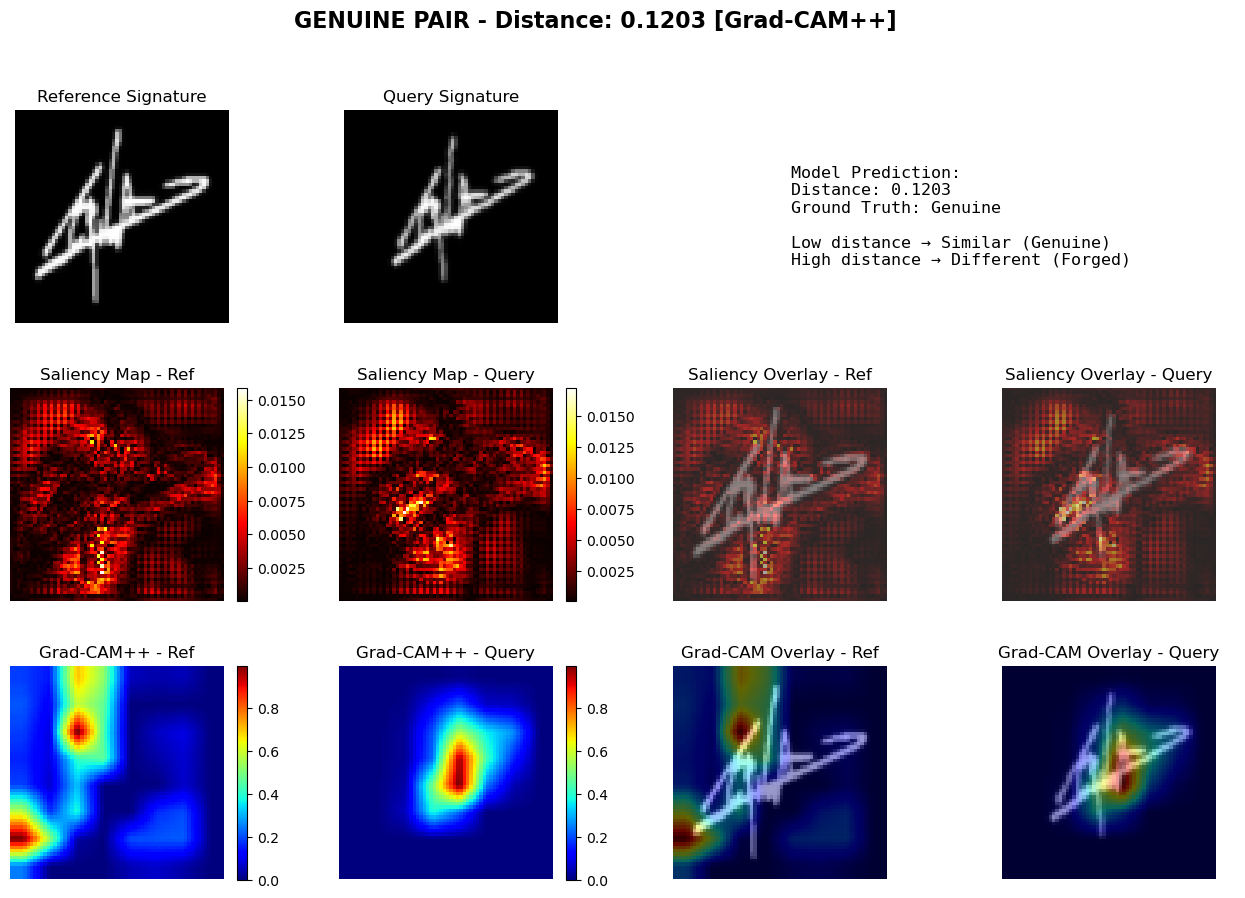

Saved: sample_visualizations/pair_1_genuine pair_dist0.091.png


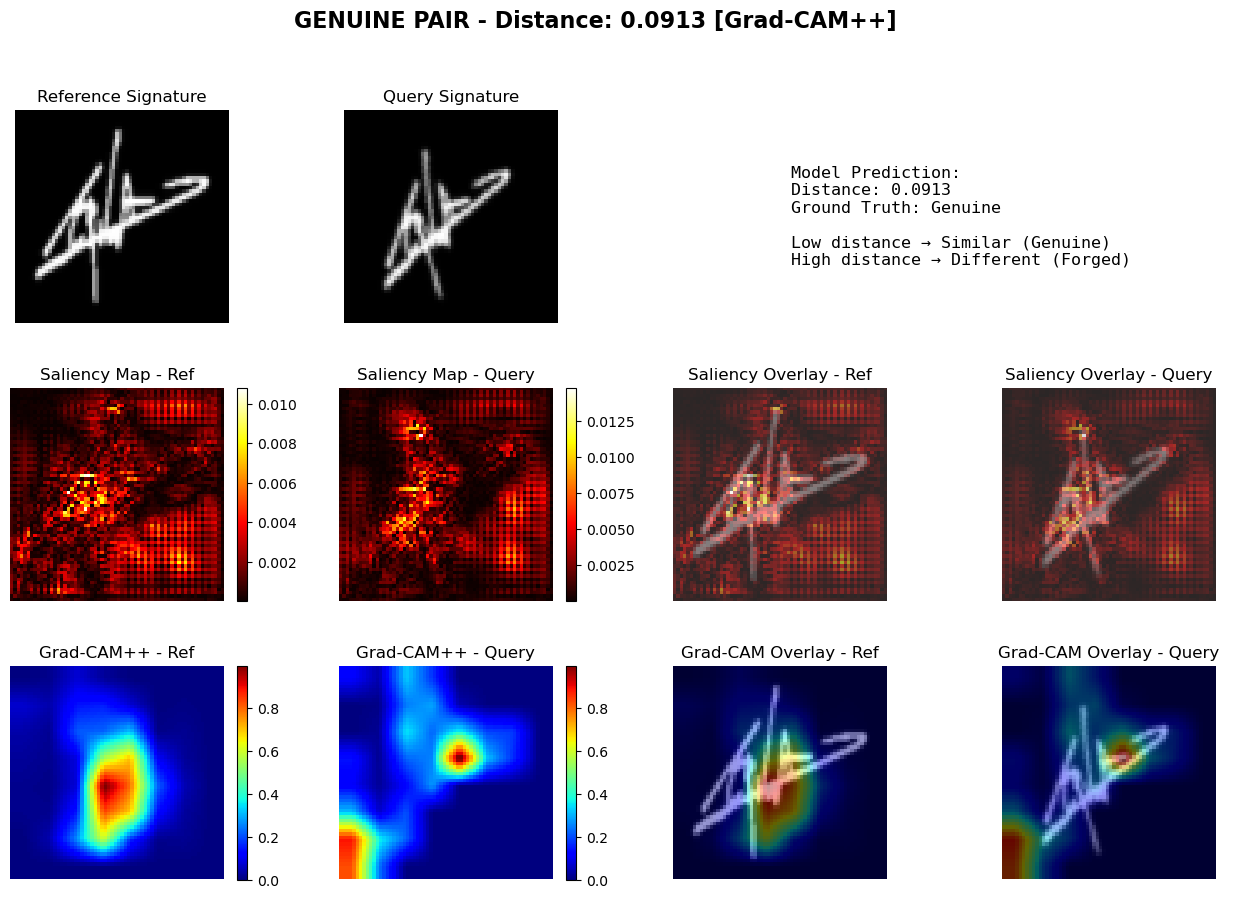

Saved: sample_visualizations/pair_2_genuine pair_dist0.149.png


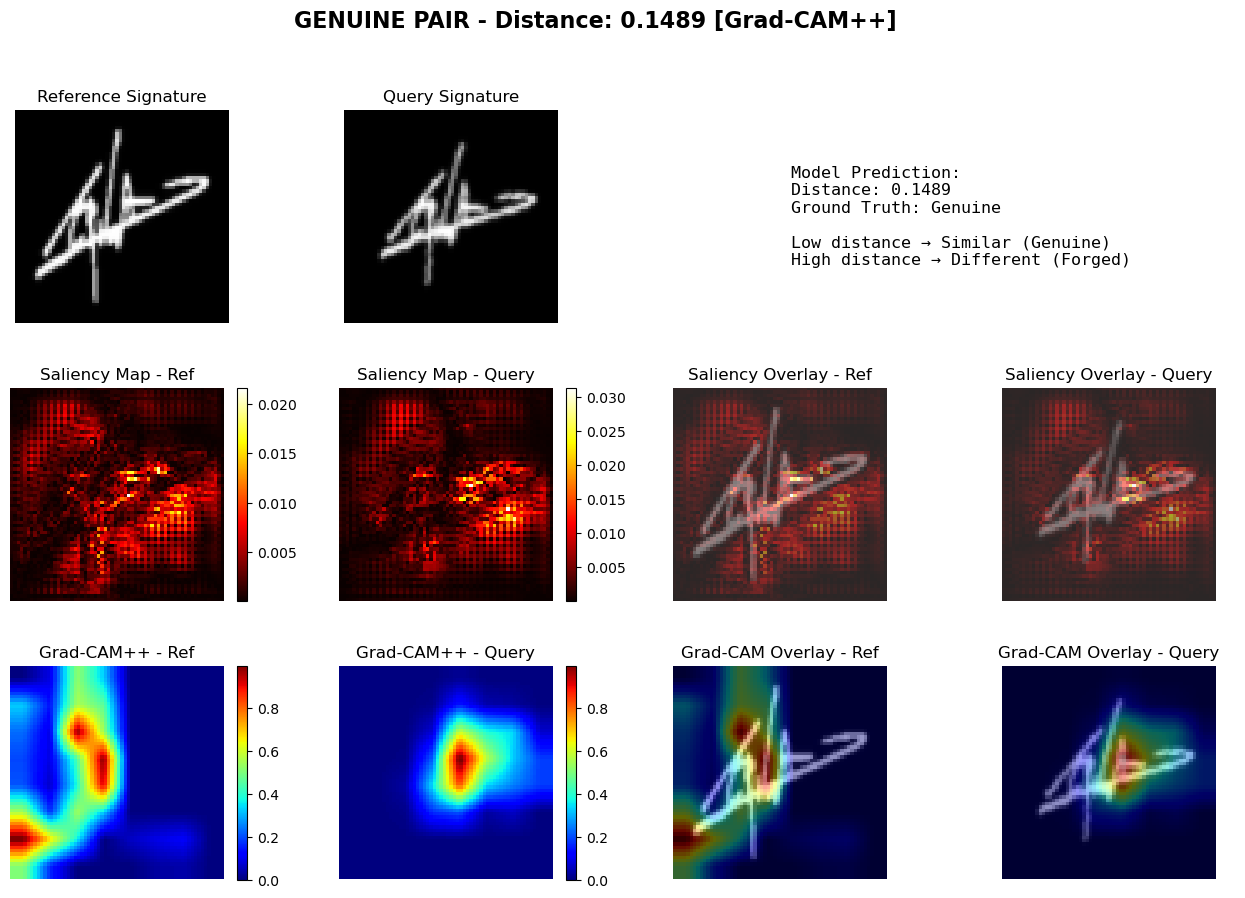

Saved: sample_visualizations/pair_3_forged pair_dist1.307.png


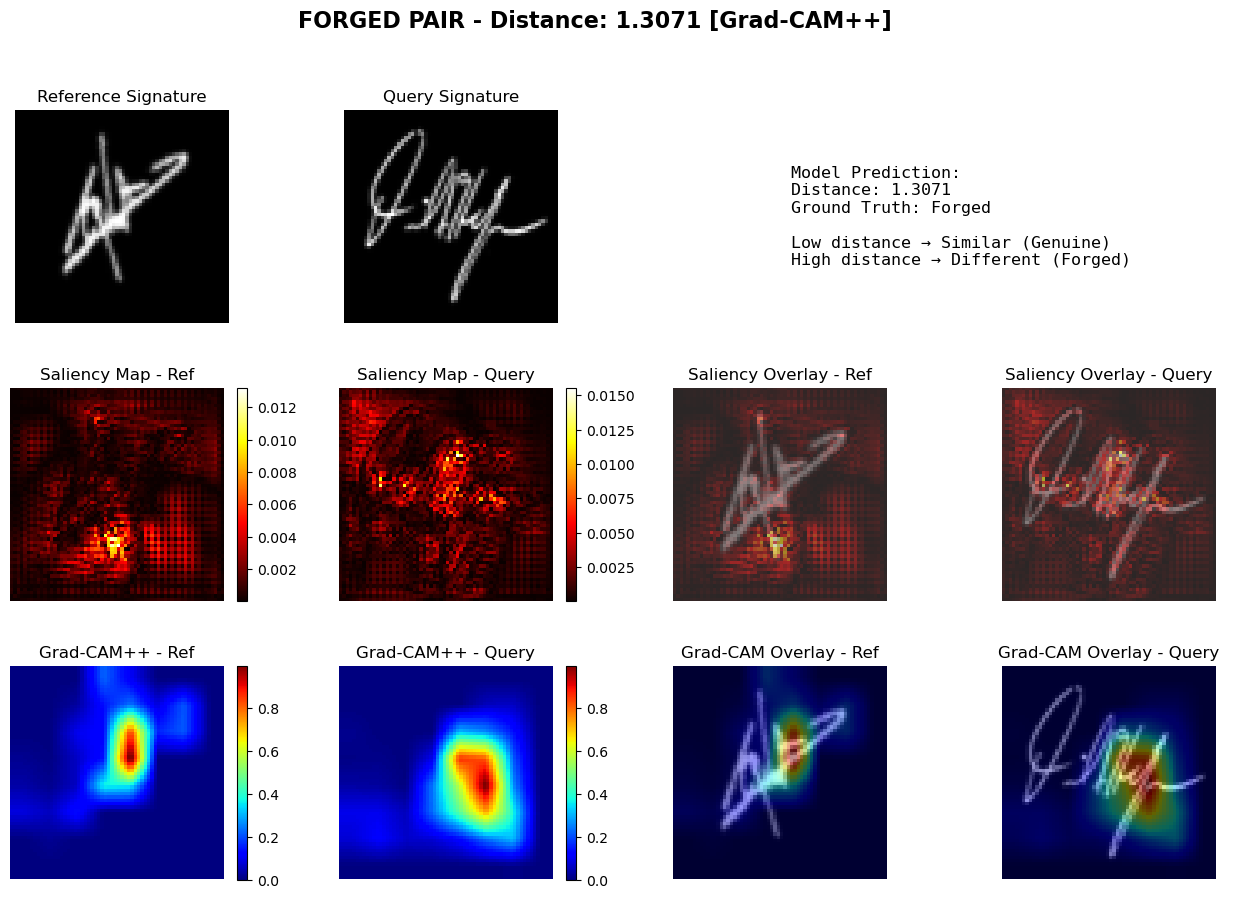

Saved: sample_visualizations/pair_4_forged pair_dist0.570.png


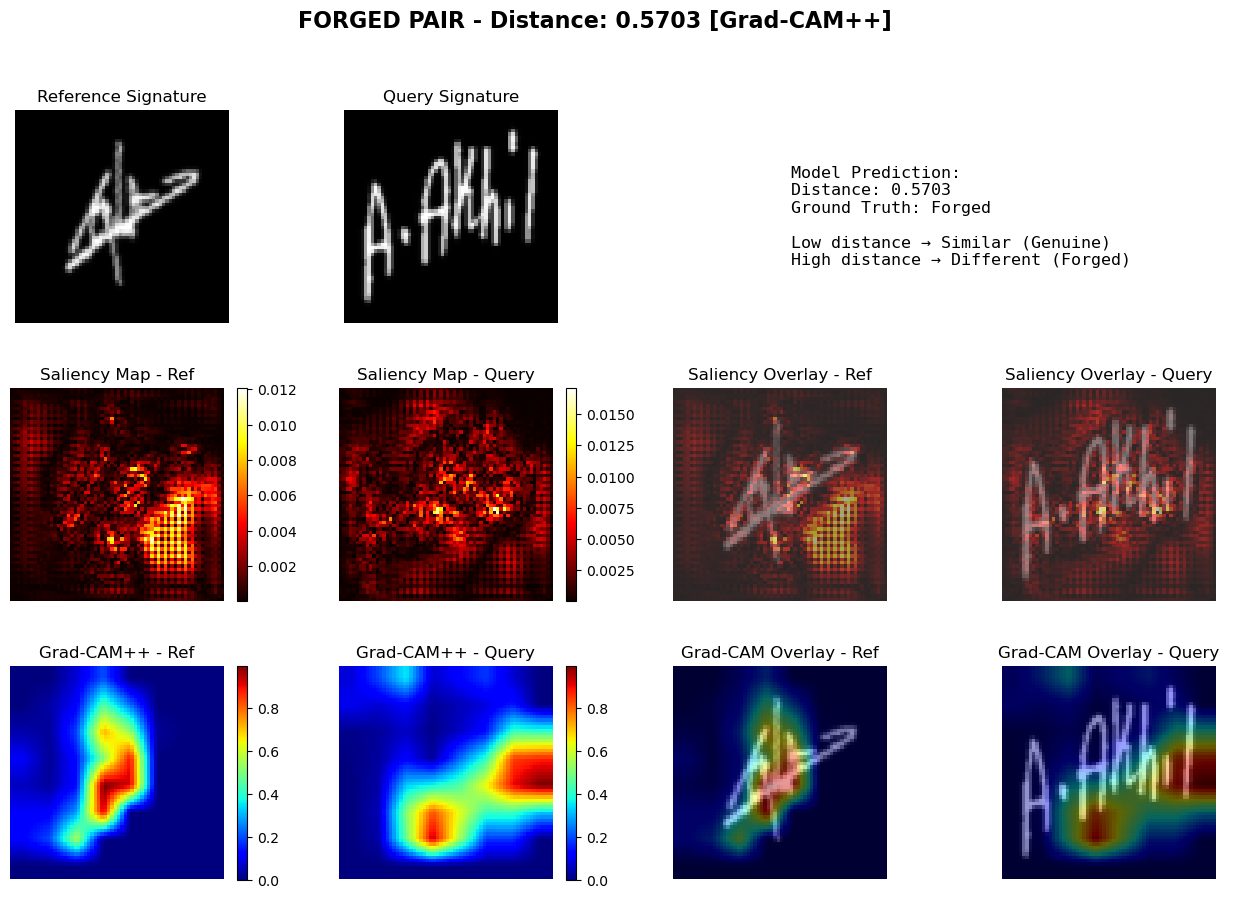

✓ Visualized 5 pairs

Computing statistical focus analysis...


Computing saliency:   1%|▊                                                              | 1/73 [00:08<09:36,  8.01s/it]


✓ Collected 50 genuine, 50 forged


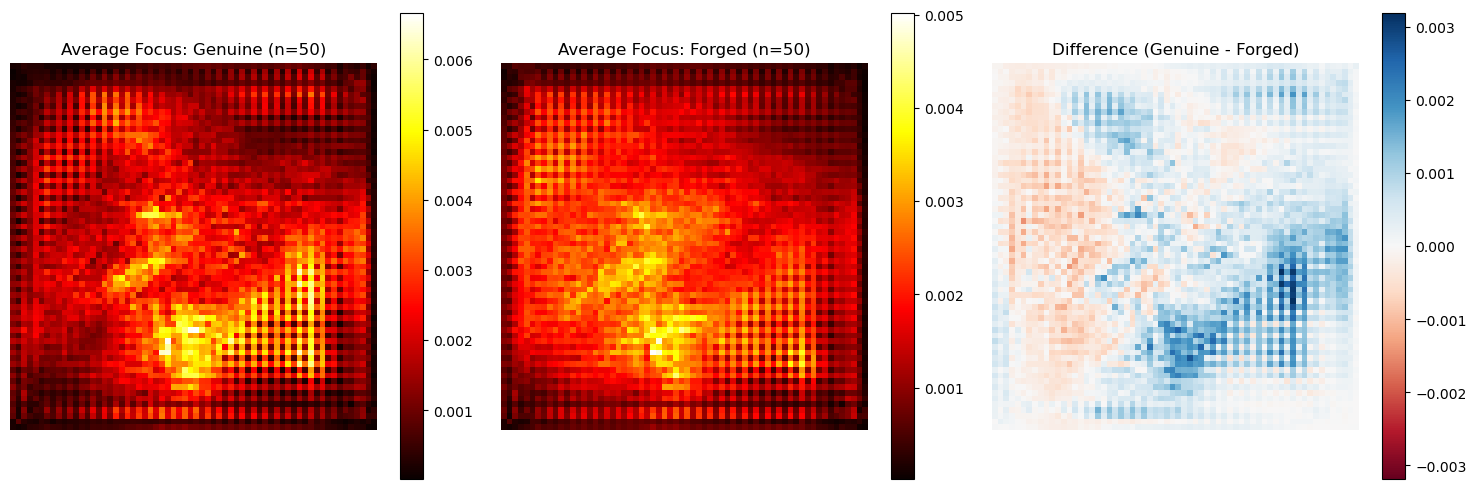


FOCUS STATISTICS

Genuine: Center/Edge = 1.57
Forged:  Center/Edge = 1.62

✓ GOOD: Model focuses on center

✓ All analysis complete!


In [14]:

# ─── Cell 1: Import and Setup ─────────────────────────────────────────
import saliency_visualization
import importlib
from tqdm import tqdm

# Reload to get latest changes
importlib.reload(saliency_visualization)
from saliency_visualization import SaliencyVisualizer, analyze_model_focus
# best_model_path='best_model_optimized.pt'
# Load your best model
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()

print("✓ Saliency visualization module loaded")
print(f"✓ Model loaded from: {best_model_path}")


# ─── Cell 2: Quick Test ───────────────────────────────────────────────
print("Testing visualizations...")

visualizer = SaliencyVisualizer(model, device)

for img1, img2, labels in test_dataloader:
    try:
        # Test saliency
        sal1, sal2, dist = visualizer.compute_saliency(
            img1[0:1].clone(), 
            img2[0:1].clone(), 
            labels[0].item()
        )
        print(f"✓ Saliency: shapes={sal1.shape}, distance={dist:.4f}")
        
        # Test Grad-CAM
        gradcam1, gradcam2 = visualizer.compute_gradcam_library(
            img1[0:1].clone(),
            img2[0:1].clone()
        )
        print(f"✓ Grad-CAM: shapes={gradcam1.shape}, max={gradcam1.max():.4f}")
        print(f"  Using: {'Library (Grad-CAM++)' if visualizer.use_library else 'Fallback'}")
        
        print("\n✓ All visualizations working!")
        break
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()
        break


# ─── Cell 3: Visualize Sample Pairs ───────────────────────────────────
print("\nVisualizing sample pairs...")

visualizer = SaliencyVisualizer(model, device)

sample_count = 0
genuine_count = 0
forged_count = 0

for img1, img2, labels in val_dataloader:
    for i in range(len(labels)):
        if sample_count >= 5:
            break
        
        label = labels[i].item()
        
        if label == 1 and genuine_count < 3:
            visualizer.visualize_pair(
                img1[i:i+1].clone(),
                img2[i:i+1].clone(),
                label,
                save_path='sample_visualizations',
                pair_idx=sample_count
            )
            genuine_count += 1
            sample_count += 1
        elif label == 0 and forged_count < 2:
            visualizer.visualize_pair(
                img1[i:i+1].clone(),
                img2[i:i+1].clone(),
                label,
                save_path='sample_visualizations',
                pair_idx=sample_count
            )
            forged_count += 1
            sample_count += 1
    
    if sample_count >= 5:
        break

print(f"✓ Visualized {sample_count} pairs")


# ─── Cell 4: Statistical Focus Analysis ───────────────────────────────
print("\nComputing statistical focus analysis...")

visualizer = SaliencyVisualizer(model, device)

genuine_saliency_maps = []
forged_saliency_maps = []
num_analyze = 50

genuine_count = 0
forged_count = 0

for img1, img2, labels in tqdm(val_dataloader, desc="Computing saliency"):
    for i in range(len(labels)):
        if genuine_count >= num_analyze and forged_count >= num_analyze:
            break
        
        label = labels[i].item()
        
        try:
            sal1, sal2, dist = visualizer.compute_saliency(
                img1[i:i+1].clone(),
                img2[i:i+1].clone(),
                label
            )
            
            if sal1.shape != (64, 64) or sal2.shape != (64, 64):
                continue
            
            avg_sal = (sal1 + sal2) / 2
            
            if label == 1 and genuine_count < num_analyze:
                genuine_saliency_maps.append(avg_sal)
                genuine_count += 1
            elif label == 0 and forged_count < num_analyze:
                forged_saliency_maps.append(avg_sal)
                forged_count += 1
        except:
            continue
    
    if genuine_count >= num_analyze and forged_count >= num_analyze:
        break

print(f"✓ Collected {len(genuine_saliency_maps)} genuine, {len(forged_saliency_maps)} forged")

# Compute and visualize
if len(genuine_saliency_maps) > 0 and len(forged_saliency_maps) > 0:
    genuine_avg = np.mean(genuine_saliency_maps, axis=0)
    forged_avg = np.mean(forged_saliency_maps, axis=0)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    im0 = axes[0].imshow(genuine_avg, cmap='hot')
    axes[0].set_title(f'Average Focus: Genuine (n={len(genuine_saliency_maps)})')
    axes[0].axis('off')
    plt.colorbar(im0, ax=axes[0])
    
    im1 = axes[1].imshow(forged_avg, cmap='hot')
    axes[1].set_title(f'Average Focus: Forged (n={len(forged_saliency_maps)})')
    axes[1].axis('off')
    plt.colorbar(im1, ax=axes[1])
    
    difference = genuine_avg - forged_avg
    vmax = max(abs(difference.min()), abs(difference.max()))
    im2 = axes[2].imshow(difference, cmap='RdBu', vmin=-vmax, vmax=vmax)
    axes[2].set_title('Difference (Genuine - Forged)')
    axes[2].axis('off')
    plt.colorbar(im2, ax=axes[2])
    
    plt.tight_layout()
    plt.savefig('average_saliency_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    def compute_focus_stats(saliency_maps):
        center_vals, edge_vals = [], []
        for sal in saliency_maps:
            h, w = sal.shape
            center_mask = np.zeros_like(sal)
            center_mask[h//4:3*h//4, w//4:3*w//4] = 1
            center_vals.append(sal[center_mask == 1].mean())
            edge_vals.append(sal[center_mask == 0].mean())
        return {
            'center_mean': np.mean(center_vals),
            'edge_mean': np.mean(edge_vals),
            'ratio': np.mean(center_vals) / (np.mean(edge_vals) + 1e-8)
        }
    
    genuine_stats = compute_focus_stats(genuine_saliency_maps)
    forged_stats = compute_focus_stats(forged_saliency_maps)
    
    print("\n" + "="*60)
    print("FOCUS STATISTICS")
    print("="*60)
    print(f"\nGenuine: Center/Edge = {genuine_stats['ratio']:.2f}")
    print(f"Forged:  Center/Edge = {forged_stats['ratio']:.2f}")
    
    if genuine_stats['ratio'] > 2.0 and forged_stats['ratio'] > 2.0:
        print("\n✓ EXCELLENT: Model focuses on signature content")
    elif genuine_stats['ratio'] > 1.5 and forged_stats['ratio'] > 1.5:
        print("\n✓ GOOD: Model focuses on center")
    else:
        print("\n⚠️ WARNING: Model may learn edge artifacts")


print("\n✓ All analysis complete!")

Validation Accuracy (optimal threshold=0.432): 0.8930
Accuracy:  0.8930
Precision: 0.8657
Recall:    0.9303
F1-score:  0.8968
AUC:       0.9547

Distance Statistics:
  Genuine mean: 0.266 ± 0.104
  Forged mean:  0.713 ± 0.251


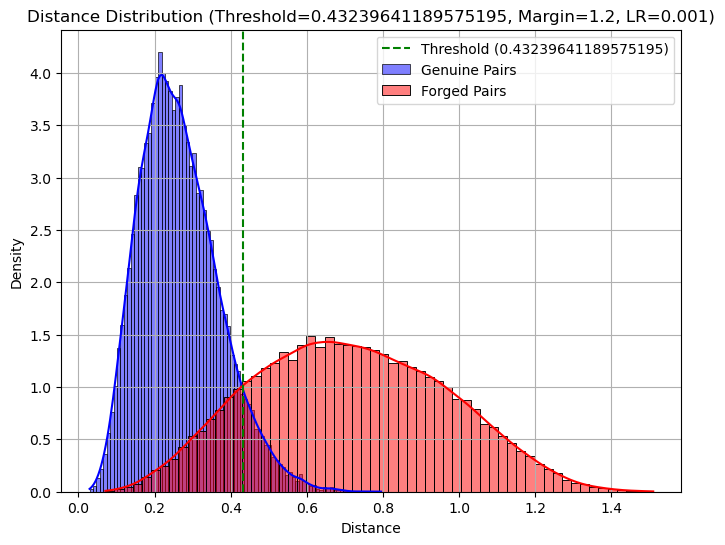

In [20]:
val_losses = []
distance_all = []
labels_all = []
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.eval()
with torch.no_grad():
    for img1_array, img2, labels in train_dataloader:
        # Use only first reference
        img1 = img1_array.to(device, non_blocking=True)
        #img1 = img1_array.to(device, non_blocking=True)
        img2 = img2.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
    
        with autocast("cuda", dtype=torch.bfloat16):
            emb1 = model(img1)
            emb2 = model(img2)
    
        distance = F.pairwise_distance(emb1, emb2)
        distance_all.append(distance)
        labels_all.append(labels)
    
        val_batch_loss = focal_loss_fn(emb1, emb2, labels)
        val_losses.append(val_batch_loss.item())

# Aggregate
distance_all = torch.cat(distance_all)
labels_all = torch.cat(labels_all)
avg_val_loss = sum(val_losses) / len(val_losses)

# ─── Threshold tuning (FIXED!) ───────────────────────────────
y_true = labels_all.cpu().numpy()  # ← THIS WAS MISSING!

# Method 1: Simple negation approach (recommended)
similarity_scores = -distance_all.cpu().numpy()
fpr, tpr, thresholds_roc = roc_curve(y_true, similarity_scores)
optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = -thresholds_roc[optimal_idx]  # Convert back to distance

y_pred = (distance_all.cpu().numpy() < optimal_threshold).astype(int)
y_pred_optimal = (distance_all.cpu().numpy() < optimal_threshold).astype(int)

print(f"Validation Accuracy (optimal threshold={optimal_threshold:.3f}): {accuracy_score(y_true, y_pred_optimal):.4f}")
print(f"Accuracy:  {accuracy_score(y_true, y_pred):.4f}")
print(f"Precision: {precision_score(y_true, y_pred):.4f}")
print(f"Recall:    {recall_score(y_true, y_pred):.4f}")
print(f"F1-score:  {f1_score(y_true, y_pred):.4f}")
print(f"AUC:       {roc_auc_score(y_true, similarity_scores):.4f}")
print(f"\nDistance Statistics:")
print(f"  Genuine mean: {distance_all[labels_all==1].mean():.3f} ± {distance_all[labels_all==1].std():.3f}")
print(f"  Forged mean:  {distance_all[labels_all==0].mean():.3f} ± {distance_all[labels_all==0].std():.3f}")
indices = np.random.permutation(len(labels_all))
distance_np = distance_all[indices].cpu().numpy()
labels_np = labels_all[indices].cpu().numpy()
distance_genuine = distance_np[labels_np == 1].tolist()
distance_forged = distance_np[labels_np == 0].tolist()

plt.figure(figsize=(8, 6))
sns.histplot(distance_genuine, color='blue', label='Genuine Pairs', kde=True, stat='density')
sns.histplot(distance_forged, color='red', label='Forged Pairs', kde=True, stat='density')
plt.axvline(x=optimal_threshold, color='green', linestyle='--', label=f'Threshold ({optimal_threshold})')
plt.xlabel('Distance')
plt.ylabel('Density')
plt.title(f'Distance Distribution (Threshold={optimal_threshold}, Margin={margin}, LR={lr})')
plt.legend()
plt.grid(True)
# plt.savefig(f"second_saved_models/saved_models/LENET/cosine_sim/cosine_similarity_distribution_threshold_{threshold}_{margin}_{lr}.png")
plt.show()  # Display the plot
plt.close()